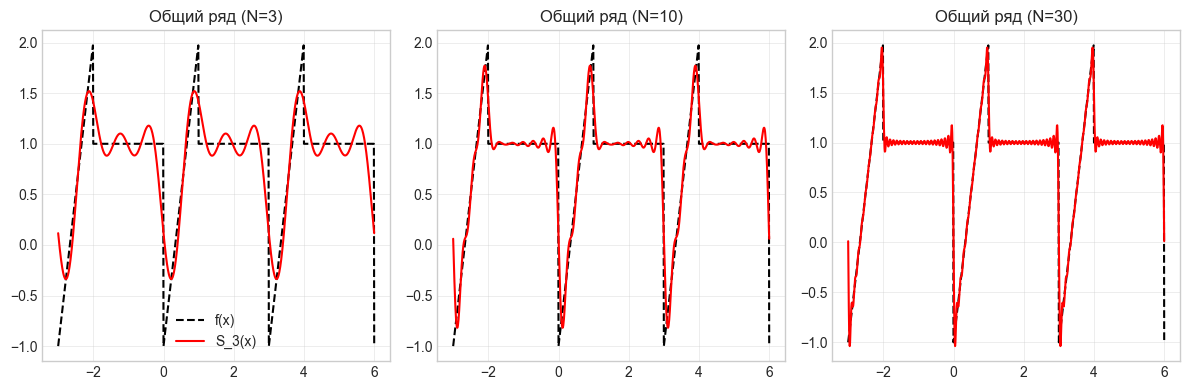

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Исходная функция f(x)
def f_original(x):
    y = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        # Приводим к периоду [0, 3)
        xi = x[i] % 3

        if 0 <= xi < 1:
            y[i] = 3 * xi - 1
        else: # 1 <= xi < 3
            y[i] = 1
    return y

# 1. Частичная сумма общего ряда Фурье
# a_0 = 5/3, период T = 3, l = 1.5
def fourier_general(x, N):
    a0 = 5 / 3
    summa = np.full_like(x, a0 / 2)

    for n in range(1, N + 1):
        k = 2 * n * np.pi / 3
        # Формулы из первой части
        an = (1 / (n * np.pi)) * np.sin(2 * n * np.pi / 3) + (9 / (2 * (n**2) * (np.pi**2))) * (np.cos(2 * n * np.pi / 3) - 1)
        bn = -(1 / (n * np.pi)) * (np.cos(2 * n * np.pi / 3) + 2) + (9 / (2 * (n**2) * (np.pi**2))) * np.sin(2 * n * np.pi / 3)

        summa += an * np.cos(k * x) + bn * np.sin(k * x)

    return summa

# 2. Частичная сумма ряда Фурье по косинусам (четное продолжение)
# Период T = 6
def fourier_cos(x, N):
    a0 = 5 / 3
    summa = np.full_like(x, a0 / 2)

    for n in range(1, N + 1):
        k = n * np.pi / 3
        an = (2 / (n * np.pi)) * np.sin(n * np.pi / 3) + (18 / ((n**2) * (np.pi**2))) * (np.cos(n * np.pi / 3) - 1)
        summa += an * np.cos(k * x)

    return summa

# 3. Частичная сумма ряда Фурье по синусам (нечетное продолжение)
# Период T = 6
def fourier_sin(x, N):
    summa = np.zeros_like(x)

    for n in range(1, N + 1):
        k = n * np.pi / 3
        # bn для нечетного продолжения (интеграл от 0 до 3, умноженный на 2/3)
        bn = (-2 / (n * np.pi)) * (np.cos(n * np.pi / 3) + 2) + (18 / ((n**2) * (np.pi**2))) * np.sin(n * np.pi / 3)
        summa += bn * np.sin(k * x)

    return summa


# Задаем массив точек для отрисовки графиков
X = np.linspace(-3, 6, 1000)

# Число слагаемых для графиков
N_values = [3, 10, 30]

# Построение графиков для Общего ряда
plt.figure(figsize=(12, 4), facecolor='white')
for i, N in enumerate(N_values):
    plt.subplot(1, 3, i + 1)
    plt.plot(X, f_original(X), 'k--', label='f(x)')
    plt.plot(X, fourier_general(X, N), 'r', label=f'S_{N}(x)')
    plt.title(f'Общий ряд (N={N})')
    plt.grid(True)
    if i == 0: plt.legend()
plt.tight_layout()
plt.show()

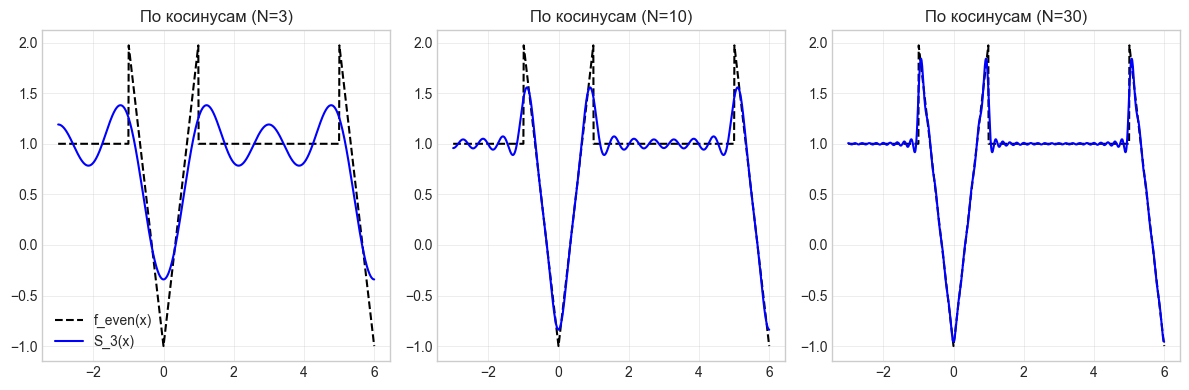

In [21]:
def f_even(x):
    y = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        # Приводим к периоду [-3, 3)
        xi = (x[i] + 3) % 6 - 3

        if xi >= 0: # Правая половина
            if xi < 1:
                y[i] = 3 * xi - 1
            else:
                y[i] = 1
        else: # Левая половина (xi < 0)
            if xi > -1:
                y[i] = 3 * (-xi) - 1  # Отражение функции 3x - 1
            else:
                y[i] = 1
    return y

# Построение графиков для ряда по косинусам
plt.figure(figsize=(12, 4), facecolor='white')
for i, N in enumerate(N_values):
    plt.subplot(1, 3, i + 1)
    # Для косинусов рисуем четное продолжение
    plt.plot(X, f_even(X), 'k--', label='f_even(x)')
    plt.plot(X, fourier_cos(X, N), 'b', label=f'S_{N}(x)')
    plt.title(f'По косинусам (N={N})')
    plt.grid(True)
    if i == 0: plt.legend()
plt.tight_layout()
plt.show()

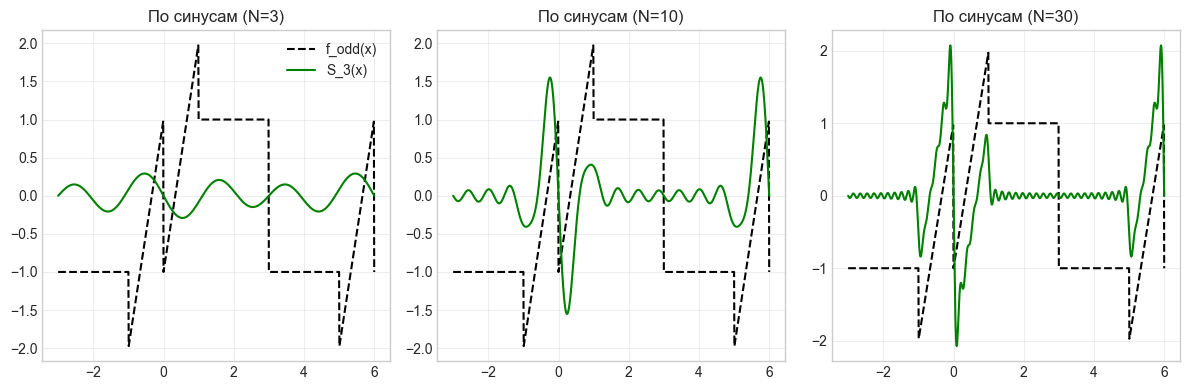

In [22]:
def f_odd(x):
    y = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        # Приводим к периоду [-3, 3)
        xi = (x[i] + 3) % 6 - 3

        if xi >= 0: # Правая половина
            if xi < 1:
                y[i] = 3 * xi - 1
            else:
                y[i] = 1
        else: # Левая половина (xi < 0) с переворотом знака всей функции
            if xi > -1:
                y[i] = -(3 * (-xi) - 1)  # Минус перед всей отраженной функцией
            else:
                y[i] = -1
    return y

# Построение графиков для ряда по синусам
plt.figure(figsize=(12, 4), facecolor='white')
for i, N in enumerate(N_values):
    plt.subplot(1, 3, i + 1)
    # Для синусов рисуем нечетное продолжение
    plt.plot(X, f_odd(X), 'k--', label='f_odd(x)')
    plt.plot(X, fourier_sin(X, N), 'g', label=f'S_{N}(x)')
    plt.title(f'По синусам (N={N})')
    plt.grid(True)
    if i == 0: plt.legend()
plt.tight_layout()
plt.show()
